In [2]:
import glob
import os
import pickle
import types
import datetime
import importlib as il
import numpy as np
import matplotlib.pyplot as plt
import dplus.g_r as g_r
from readline import callback_read_char
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.special import erfcx, gamma
from scipy.constants import k as kB

from New_DW import calc_DW

%matplotlib inline

In [1]:
SESSION_FILE = ".\\Results\\Variance_session.pkl"

def _is_data(name, val):
    """Keep plain data: skip privates, modules, functions, classes, IPython junk."""
    if name.startswith('_'):
        return False
    if name in ('In', 'Out', 'exit', 'quit', 'get_ipython', 'open',
                'SESSION_FILE', 'save_session', 'load_session'):
        return False
    if isinstance(val, (types.ModuleType, types.FunctionType, types.BuiltinFunctionType,
                        types.MethodType, type)):
        return False
    return True


def save_session(path=SESSION_FILE, namespace=None, verbose=False):
    """Pickle all data variables of the notebook namespace into one file."""
    ns = globals() if namespace is None else namespace
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)

    saved, skipped = {}, []
    for name, val in list(ns.items()):
        if not _is_data(name, val):
            continue
        try:
            pickle.dumps(val)          # test-pickle so one bad object cannot kill the dump
            saved[name] = val
        except Exception as e:
            skipped.append((name, type(val).__name__, str(e)[:60]))

    with open(path, 'wb') as f:
        pickle.dump(saved, f, protocol=pickle.HIGHEST_PROTOCOL)

    if verbose:
        size_mb = os.path.getsize(path) / 1024 ** 2
        print(f"saved {len(saved)} variables -> {path}  ({size_mb:.1f} MB, "
              f"{datetime.datetime.now():%Y-%m-%d %H:%M})")
        if skipped:
            print("skipped (not picklable):")
            for name, typ, err in skipped:
                print(f"  {name:<25s} {typ:<20s} {err}")
    return sorted(saved)


def load_session(path=SESSION_FILE, namespace=None, overwrite=True, verbose=True):
    """Restore variables saved by save_session into the notebook namespace."""
    ns = globals() if namespace is None else namespace
    exist = os.path.isfile(path)
    if exist:
        with open(path, 'rb') as f:
            data = pickle.load(f)

        loaded, kept = [], []
        for name, val in data.items():
            if not overwrite and name in ns:
                kept.append(name)
                continue
            ns[name] = val
            loaded.append(name)

        if verbose:
            print(f"loaded {len(loaded)} variables from {path}")
            if kept:
                print(f"kept existing (overwrite=False): {', '.join(sorted(kept))}")
            print(', '.join(sorted(loaded)))

        return sorted(loaded)

    else:
        print("No file found, nothing was loaded. Continuing run.")
        return

# save_session()     # run after a long computation

# load_session()     # run in a fresh kernel instead of re-computing

# Define functions for fitting and analysis and basic parameters

In [6]:
import csv


def write_to_out_origin(out_file, q, I, model, perc_val=None):
    """Write a two-column .out file with an OriginLab three-line header.

    Origin reads the first line as the long name, the second as the units and
    the third as the comment, so the comment row carries the modelled sigma.
    `model` is the subscript of sigma ("uncorr" for the Einstein model) and
    `perc_val` is the fractional displacement, so perc_val = 0.005 prints
    sigma_model = 0.5% x d. Pass perc_val = None for a rigid lattice.
    """
    if not out_file.endswith('.out'):
        out_file = out_file.rsplit('.', 1)[0] + '.out'

    if perc_val is None:
        comment = r"\q(\sigma_{%s} = 0)" % model
    else:
        comment = r"\q(\sigma_{%s} = %g\%%\times d)" % (model, perc_val * 100)

    with open(out_file, 'w', newline='', encoding='utf-8') as f:
        f.write("q\tStructure Factor\n")
        f.write("\\q(nm^{-1})\t\n")
        f.write("\t" + comment + "\n")
        writer = csv.writer(f, delimiter='\t', quoting=csv.QUOTE_NONNUMERIC)
        for i in range(q.shape[0]):
            writer.writerow([q[i], I[i]])
    return


In [3]:
def linear_func(x, a, b):
    return a * x + b

In [ ]:
def C_bond(reps):
    """Mean bond variance in units of sigma_b^2, from Foster's theorem: sum_edges R_ij = n - 1."""
    N1, N2, N3 = (int(r) for r in reps)
    E = (N1 - 1) * N2 * N3 + N1 * (N2 - 1) * N3 + N1 * N2 * (N3 - 1)
    return (N1 * N2 * N3 - 1) / E

In [4]:
def R_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    return r_squared

In [5]:
def chi2(obs, exp, sigma, n_params=0):
  r = (obs - exp) / sigma
  chi2 = np.sum(r**2)
  dof = len(obs) - n_params

  return chi2, chi2 / dof

In [8]:
def calc_DW(q, sq0, sigma):
    return np.exp(-q**2 * sigma**2) * (sq0 - 1) + 1
    # return sq0 * np.exp(-q**2 * sigma_sq[-1]) + 1 - np.exp(-q**2 * sigma_sq[-1])

In [16]:
# def find_sigma_factor(lattice):
#     V_cell = np.sqrt(np.abs(np.linalg_r.det(lattice @ lattice.T)))
#     k_D = np.power(6 * np.pi**2 / V_cell, 1/3)
#     fact = 3 * k_D * np.power(V_cell, 1/3) / (2 * np.pi**2)
#     return fact

In [22]:
d = 2 * np.pi
n_reps = 15**3
n_reps_2d = round(n_reps ** 0.5)
n_reps_3d = round(n_reps ** (1/3))

q_min = 0
q_max = 5.5
dq = 0.01
q = np.arange(q_min, q_max + dq, dq)
len_q = len(q)


os.makedirs(".\\DOL\\", exist_ok=True)
os.makedirs(".\\Results\\", exist_ok=True)
dol_in_fmt = f".\\DOL\\variance_session_dims_%i_N_%i_d_{d:.4f}.dol"
dol_out_fmt = f".\\DOL\\variance_session_dims_%i_N_%i_d_{d:.4f}_perc_%.3f.dol"

# S(q) in Crystals

In [23]:
perc      = np.array([1, 5, 10]) / 100
len_p     = len(perc)
sigma     = perc * d
sigma_sq  = sigma ** 2
k_spring  = 1 / sigma_sq
temp      = 298
max_dist  = 1.3 * d
step_size = 0
# MC_Sim_GPU_sweep counts pop_out_num / min_accepted in PROPOSALS, not accepted states,
# so nothing here has to be recalibrated against the acceptance rate any more.
sweeps       = 20_000                   # sweeps of all 729 atoms
burn_in      = 100                    # sweeps discarded before the first snapshot
snap_every   = 50                      # sweeps between snapshots -> ~398 snapshots

iterations   = sweeps     * n_reps      # 14_580_000 single-atom proposals
min_accepted = burn_in    * n_reps
pop_out_num  = snap_every * n_reps
record_every = n_reps

lattice_1d = np.array([[0, 0, 0], [0, 0, 0], [0, 0, d]])
dol_1d = g_r.build_crystal(lattice_1d, 1, 1, n_reps, dol_in_fmt %(1, n_reps))

lattice_2d = np.array([[0, 0, 0], [0, d, 0], [0, 0, d]])
dol_2d = g_r.build_crystal(lattice_2d, 1, n_reps_2d, n_reps_2d, dol_in_fmt %(2, n_reps_2d))

lattice_3d = np.array([[d, 0, 0], [0, d, 0], [0, 0, d]])
dol_3d = g_r.build_crystal(lattice_3d, n_reps_3d, n_reps_3d, n_reps_3d, dol_in_fmt %(3, n_reps_3d))

fact_3d = C_bond([n_reps_3d, n_reps_3d, n_reps_3d])
k_scale = np.array([1.0, 1 / np.pi,  fact_3d**2])

## Gauss_Well - the Einstein crystal

$$V(\mathbf{x}) = \sum_{i=1}^{N} \tfrac{1}{2} k \left|x_i - i d\right|^2,$$

In [13]:
dol_out_gw_fmt = f".\\DOL\\variance_session_dims_%i_N_%i_d_{d:.4f}_perc_%.3f_gauss_well.dol"
sq_out_gw_fmt  = f".\\Results\\variance_session_dims_%i_N_%i_d_{d:.4f}_perc_%.3f_gauss_well.out"

s_q_gw_1d = np.zeros([len_p, len_q])
s_q_gw_2d = np.zeros([len_p, len_q])
s_q_gw_3d = np.zeros([len_p, len_q])
acc_gw = np.zeros([len_p, 3])
u2_gw  = np.zeros([len_p, 3])      # measured <|u|^2>, to be compared against the exact dim / k

for k_idx in range(len_p):
    print(f"Gauss_Well: perc = {perc[k_idx]*100:.2f}%, sigma = {sigma[k_idx]:.4f}, "
          f"k = {k_spring[k_idx]:.4f} kT")

    for dims, n_rep, s_q_gw in ((1, n_reps, s_q_gw_1d),
                                (2, n_reps_2d, s_q_gw_2d),
                                (3, n_reps_3d, s_q_gw_3d)):
        dol_out = dol_out_gw_fmt % (dims, n_rep, perc[k_idx])

        _, d_vec, acc_gw[k_idx, dims - 1] = g_r.MC_Sim(dol_in_fmt % (dims, n_rep), dol_out, temp, max_dist, d, iterations, sigma[k_idx], 'Gauss_Well', k_spring[k_idx], pop_out_num=pop_out_num, min_accepted=min_accepted, record_every=record_every)

        u2_gw[k_idx, dims - 1] = np.mean(d_vec[len(d_vec) // 2:] ** 2)

        snaps = sorted(glob.glob(dol_out[:-4] + "_run_*_Gauss_Well.dol"))
        for s in snaps:
            s_q_gw[k_idx] += g_r.S_Q_from_model_GPU(s, q_min, q_max, dq)[1]
        s_q_gw[k_idx] /= len(snaps)

        write_to_out_origin(sq_out_gw_fmt % (dims, n_rep, perc[k_idx]), q, s_q_gw[k_idx],
                            "uncorr", perc[k_idx])

        print(f"  {dims}D: <|u|^2> = {u2_gw[k_idx, dims - 1]:.5f} against the exact dim/k = "
              f"{dims * sigma_sq[k_idx]:.5f}, acceptance {acc_gw[k_idx, dims - 1]:.3f}, "
              f"{len(snaps)} snapshots")

Gauss_Well: perc = 0.50%, sigma = 0.0314, k = 1013.2118 kT
Gauss_Well with k = 1013: exact per-axis variance 1/k = 0.000987, <|u|^2> = dim/k = 0.000987
MC_Sim_GPU_sweep: 1D, 729 atoms, 1 colours, largest class 729, 20000 sweeps of 729 proposals, snapshot every 50 sweeps from sweep 100
sweep 100 of 20000, 72900 proposals, 51395 accepted, acceptance rate is 0.705
sweep 150 of 20000, 109350 proposals, 77057 accepted, acceptance rate is 0.705
sweep 200 of 20000, 145800 proposals, 102653 accepted, acceptance rate is 0.704
sweep 250 of 20000, 182250 proposals, 128290 accepted, acceptance rate is 0.704
sweep 300 of 20000, 218700 proposals, 154075 accepted, acceptance rate is 0.705
sweep 350 of 20000, 255150 proposals, 179632 accepted, acceptance rate is 0.704
sweep 400 of 20000, 291600 proposals, 205417 accepted, acceptance rate is 0.704
sweep 450 of 20000, 328050 proposals, 231064 accepted, acceptance rate is 0.704
sweep 500 of 20000, 364500 proposals, 256778 accepted, acceptance rate is 0.7

## Hooke Potential

$$V(\mathbf{x}) = \sum_{i=1}^{N} \tfrac{1}{2} k \left|\mathbf{x}_i - \mathbf{x}_j - d\,\hat{x}_{ij}\right|^2,$$


In [24]:
energies_1d = np.zeros([len_p, iterations//n_reps + 1])
acc_1d = np.zeros([len_p])
energies_2d = np.zeros([len_p, iterations//n_reps + 1])
acc_2d = np.zeros([len_p])
energies_3d = np.zeros([len_p, iterations//n_reps + 1])
acc_3d = np.zeros([len_p])

s_q_1d = np.zeros([len_p, len_q])
s_q_2d = np.zeros([len_p, len_q])
s_q_3d = np.zeros([len_p, len_q])

sq_out_fmt = f".\\Results\\variance_session_dims_%i_N_%i_d_{d:.4f}_perc_%.3f_HookVec_div.out"
ls_out_fmt = f".\\Results\\variance_session_dims_%i_N_%i_d_{d:.4f}_perc_%.3f_ls.out"

for k_idx, temp_k in enumerate(k_spring):
    print(f"Calculating for k = {temp_k:.4f} (perc = {perc[k_idx]*100:.2f}%)")
    energies_1d[k_idx], _, acc_1d[k_idx] = g_r.MC_Sim(
        dol_in_fmt % (1, n_reps), dol_out_fmt % (1, n_reps, perc[k_idx]),
        temp, max_dist, d, iterations, sigma[k_idx], 'HookVec', temp_k * k_scale[0],
        pop_out_num=pop_out_num, min_accepted=min_accepted, record_every=record_every)

    energies_2d[k_idx], _, acc_2d[k_idx] = g_r.MC_Sim(
        dol_in_fmt % (2, n_reps_2d), dol_out_fmt % (2, n_reps_2d, perc[k_idx]),
        temp, max_dist, d, iterations, sigma[k_idx], 'HookVec', temp_k * k_scale[1],
        pop_out_num=pop_out_num, min_accepted=min_accepted, record_every=record_every)

    energies_3d[k_idx], _, acc_3d[k_idx] = g_r.MC_Sim(
        dol_in_fmt % (3, n_reps_3d), dol_out_fmt % (3, n_reps_3d, perc[k_idx]),
        temp, max_dist, d, iterations, sigma[k_idx], 'HookVec', temp_k * k_scale[2],
        pop_out_num=pop_out_num, min_accepted=min_accepted, record_every=record_every)

    pat_1d   = dol_out_fmt %(1, n_reps, perc[k_idx])
    snaps_1d = [s for s in glob.glob(pat_1d[:-4] + "_run_*.dol")]#_*HookVec.dol")]
    pat_2d   = dol_out_fmt %(2, n_reps_2d, perc[k_idx])
    snaps_2d = [s for s in glob.glob(pat_2d[:-4] + "_run_*.dol")]#_*HookVec.dol")]
    pat_3d   = dol_out_fmt %(3, n_reps_3d, perc[k_idx])
    snaps_3d = [s for s in glob.glob(pat_3d[:-4] + "_run_*.dol")]#_*HookVec.dol")]

    print(f"Calculating S(q) in 1D for perc = {perc[k_idx]*100:.2f}%")
    for s_1d in snaps_1d:
        s_q_1d[k_idx] += g_r.S_Q_from_model_GPU(s_1d, q_min, q_max, dq)[1]


    print(f"Calculating S(q) in 2D for perc = {perc[k_idx]*100:.2f}%")
    for s_2d in snaps_2d:
        s_q_2d[k_idx] += g_r.S_Q_from_model_GPU(s_2d, q_min, q_max, dq)[1]

    print(f"Calculating S(q) in 3D for perc = {perc[k_idx]*100:.2f}%")
    for s_3d in snaps_3d:
        s_q_3d[k_idx] += g_r.S_Q_from_model_GPU(s_3d, q_min, q_max, dq)[1]


    s_q_1d[k_idx] /= len(snaps_1d)
    s_q_2d[k_idx] /= len(snaps_2d)
    s_q_3d[k_idx] /= len(snaps_3d)

    out_file_1d = sq_out_fmt %(1, n_reps, perc[k_idx])
    write_to_out_origin(out_file_1d, q, s_q_1d[k_idx], "MC", perc[k_idx])
    out_file_2d = sq_out_fmt %(2, n_reps_2d, perc[k_idx])
    write_to_out_origin(out_file_2d, q, s_q_2d[k_idx], "MC", perc[k_idx])
    out_file_3d = sq_out_fmt %(3, n_reps_3d, perc[k_idx])
    write_to_out_origin(out_file_3d, q, s_q_3d[k_idx], "MC", perc[k_idx])

Calculating for k = 253.3030 (perc = 1.00%)
frozen bond list: 3375 atoms, 9450 bonds, max coordination 6, bond lengths 6.283 to 6.283
bond directions: 3 groups, in the order a per-direction sequence is read
  [ 0] ( 0.0000,  0.0000,  1.0000)    3150 bonds, length 6.283 to 6.283
  [ 1] ( 0.0000,  1.0000,  0.0000)    3150 bonds, length 6.283 to 6.283
  [ 2] ( 1.0000,  0.0000,  0.0000)    3150 bonds, length 6.283 to 6.283
MC_Sim: Hooke on GPU, 3D, 3375 atoms, 2 colours, largest class 1688, 20000 sweeps of 3375 proposals, snapshot every 50 sweeps from sweep 100
sweep 100 of 20000, 337500 proposals, 205982 accepted, acceptance rate is 0.610
sweep 150 of 20000, 506250 proposals, 308977 accepted, acceptance rate is 0.610
sweep 200 of 20000, 675000 proposals, 412590 accepted, acceptance rate is 0.611
sweep 250 of 20000, 843750 proposals, 515667 accepted, acceptance rate is 0.611
sweep 300 of 20000, 1012500 proposals, 618611 accepted, acceptance rate is 0.611
sweep 350 of 20000, 1181250 proposa

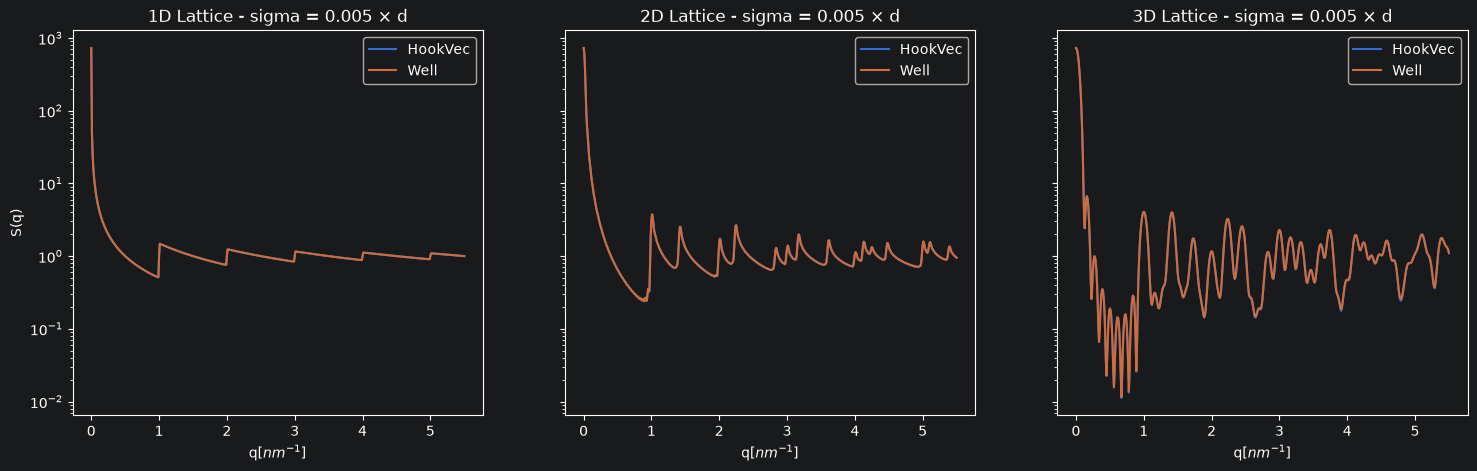

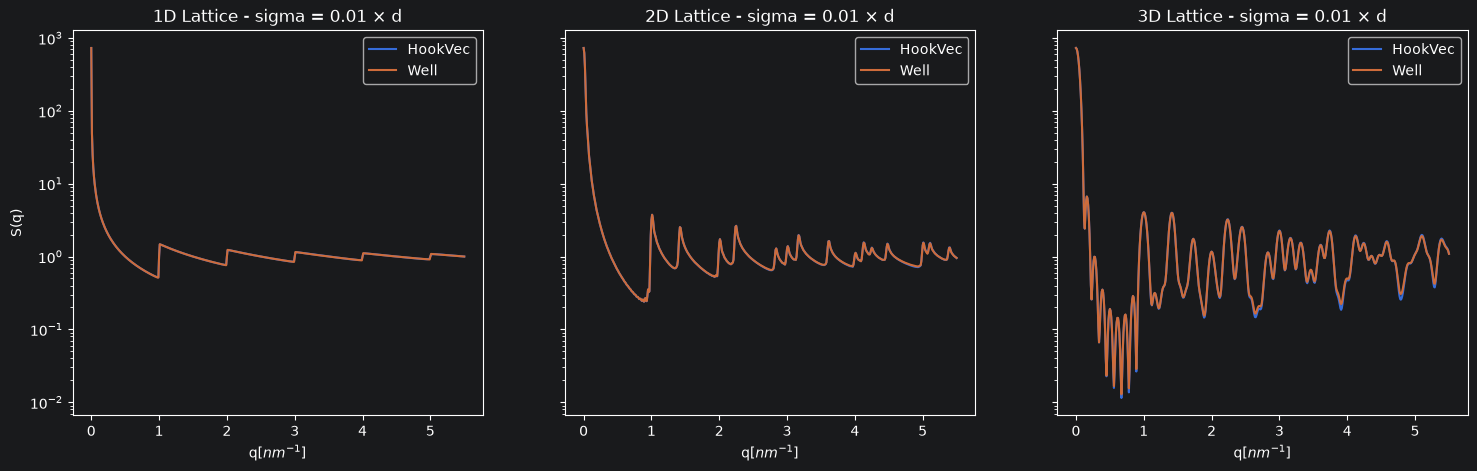

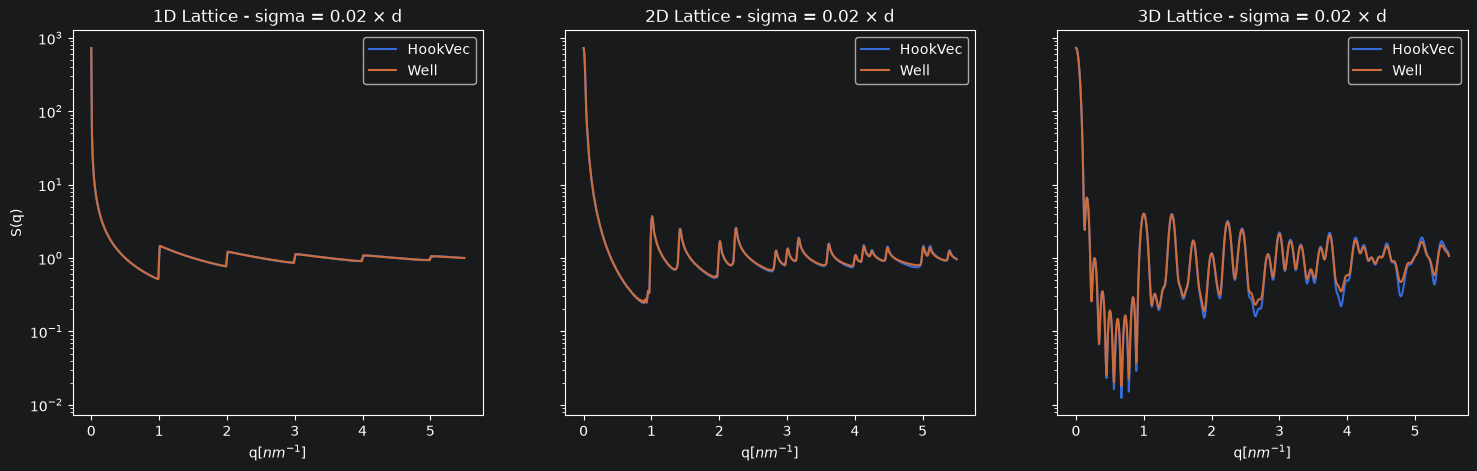

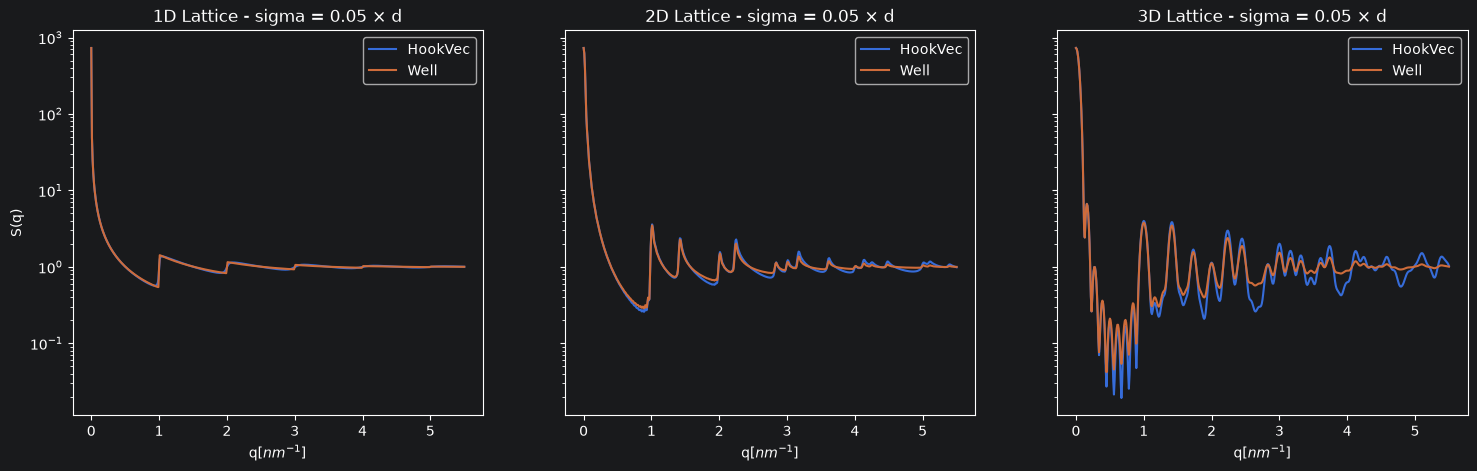

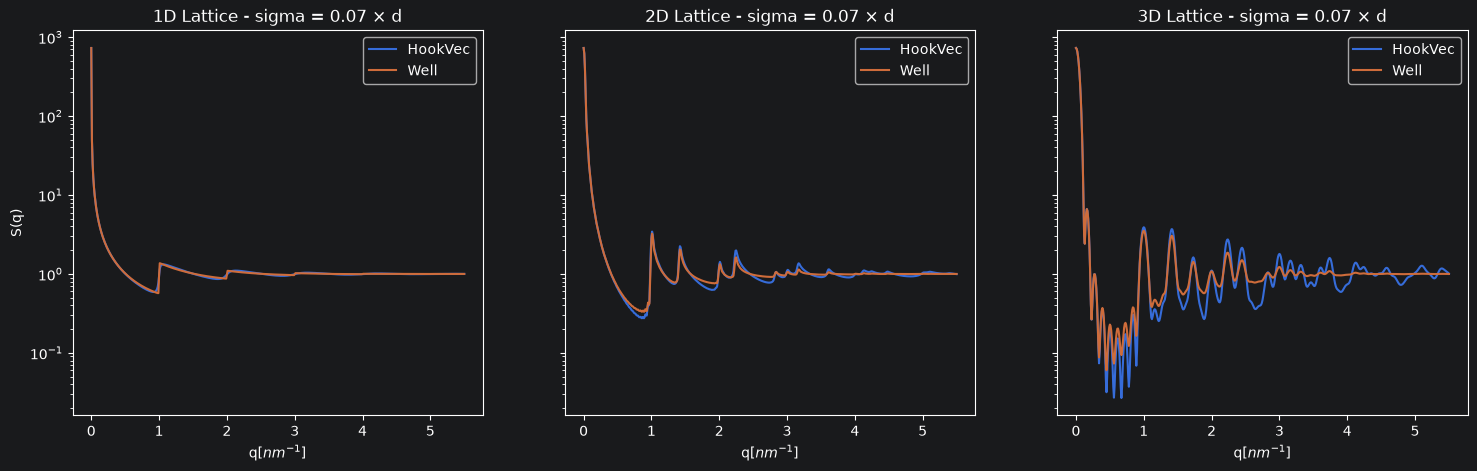

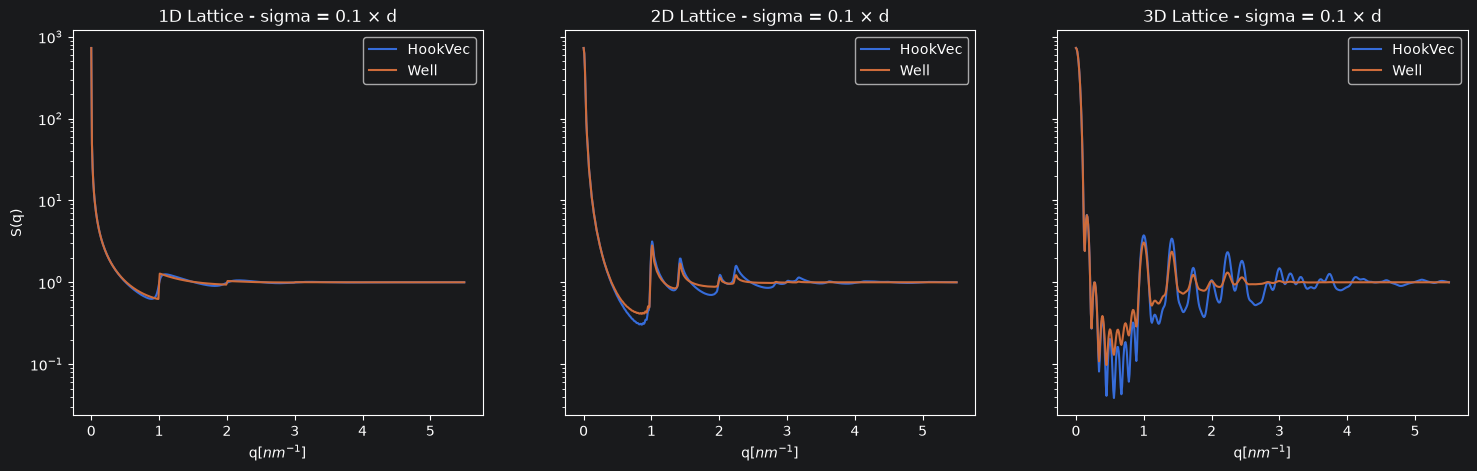

In [15]:
for i in range(len_p):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    ax[0].set_title(f"1D Lattice - sigma = {perc[i]} $\\times$ d")
    ax[0].set_xlabel("q$[nm^{-1}]$")
    ax[0].set_ylabel("S(q)")
    ax[0].semilogy(q, s_q_1d[i], label="HookVec")
    ax[0].semilogy(q, s_q_gw_1d[i], label="Well")
    ax[0].legend()
    ax[1].set_title(f"2D Lattice - sigma = {perc[i]} $\\times$ d")
    ax[1].set_xlabel("q$[nm^{-1}]$")
    ax[1].semilogy(q, s_q_2d[i], label="HookVec")
    ax[1].semilogy(q, s_q_gw_2d[i], label="Well")
    ax[1].legend()
    ax[2].set_title(f"3D Lattice - sigma = {perc[i]} $\\times$ d")
    ax[2].set_xlabel("q$[nm^{-1}]$")
    ax[2].semilogy(q, s_q_3d[i], label="HookVec")
    ax[2].semilogy(q, s_q_gw_3d[i], label="Well")
    ax[2].legend()


In [18]:
q_range = (q>=0.9) & (q<=5.1)

s_q_1d_0 = g_r.S_Q_from_model_GPU(dol_in_fmt % (1, n_reps), q_min, q_max, dq)[1]
s_q_2d_0 = g_r.S_Q_from_model_GPU(dol_in_fmt %(2, n_reps_2d), q_min, q_max, dq)[1]
s_q_3d_0 = g_r.S_Q_from_model_GPU(dol_in_fmt %(3, n_reps_3d), q_min, q_max, dq)[1]
os.makedirs(".\\Results\\", exist_ok=True)

s_q_out_1d = ".\\Results\\s_q_no_fluct_1d_N_%i.out" % n_reps
s_q_out_2d = ".\\Results\\s_q_no_fluct_2d_N_%i.out" % n_reps_2d
s_q_out_3d = ".\\Results\\s_q_no_fluct_3d_N_%i.out" % n_reps_3d

write_to_out_origin(s_q_out_1d, q, s_q_1d_0, "MC")
write_to_out_origin(s_q_out_2d, q, s_q_2d_0, "MC")
write_to_out_origin(s_q_out_3d, q, s_q_3d_0, "MC")

out_dir = ".\\Results"
header_erf = "q\tStructure Factor\n\\q(nm^{-1})\t\n\t\\q(\\sigma_{erf}=%g \\%% \\times d)"
header_dw = "q\tStructure Factor\n\\q(nm^{-1})\t\n\t\\q(\\sigma_{DW}=%g \\%% \\times d)"
header_decoupled = "q\tStructure Factor\n\\q(nm^{-1})\t\n\t\\q(\\sigma_{decoupled}=%g \\%% \\times d)"

def save_out(path_fmt, s_q, perc_value, header_tmpl):
    """Write one S(q) curve in the two-column .out format the rest of the pipeline reads."""
    np.savetxt(path_fmt % (perc_value * 100), np.column_stack((q, s_q)),
               header=header_tmpl % (perc_value * 100), delimiter="\t", comments="#")

print("Starting 1D:")
dol_1d_fmt = f".\\DOL\\variance_session_N_{n_reps}_d_{d:.4f}.dol"
my_dol_1d = g_r.build_crystal(np.array([0, 0, d, np.pi/2, np.pi/2, np.pi/2]), 1, 1, n_reps, dol_1d_fmt)

s_q_erf_1d = np.zeros([len(perc), len(q)])
s_q_einstein_1d = np.zeros([len(perc), len(q)])
s_q_dw_1d = np.zeros([len(perc), len(q)])
s_q_decoupled_1d = np.zeros([len(perc), len(q)])

out_1d_erf_springs = f"{out_dir}\\analytical_d_{d:.3f}_rep_{n_reps}_perc_%.1f_spring_r.out"
out_1d_erf_wells = f"{out_dir}\\analytical_d_{d:.3f}_rep_{n_reps}_perc_%.1f_well.out"
out_1d_decoupled = f"{out_dir}\\decoupled_d_{d:.3f}_rep_{n_reps}_perc_%.1f_spring_r.out"
out_1d_dw_wells = f"{out_dir}\\DW_d_{d:.3f}_rep_{n_reps}_perc_%.1f_well.out"

for sig_idx, sig in enumerate(sigma):
    s_q_erf_1d[sig_idx, :] = g_r.s_q_1d_analytic(q, n_reps, d, sigma[sig_idx], model='spring')
    s_q_einstein_1d[sig_idx, :] = g_r.s_q_1d_analytic(q, n_reps, d, sigma[sig_idx], model='well')
    s_q_dw_1d[sig_idx, :] = calc_DW(q, s_q_1d_0[:-1], sigma[sig_idx])
    s_q_decoupled_1d[sig_idx, :] = g_r.s_q_decoupled(q, sigma[sig_idx], 1, N=n_reps, d=d)

    save_out(out_1d_erf_springs, s_q_erf_1d[sig_idx, :], perc[sig_idx], header_erf)
    save_out(out_1d_erf_wells, s_q_einstein_1d[sig_idx, :], perc[sig_idx], header_erf)
    save_out(out_1d_decoupled, s_q_decoupled_1d[sig_idx, :], perc[sig_idx], header_decoupled)
    save_out(out_1d_dw_wells, s_q_dw_1d[sig_idx, :], perc[sig_idx], header_dw)

print("Starting 2D:")
dol_2d_fmt = f".\\DOL\\variance_session_N_{n_reps_2d}x{n_reps_2d}_d_{d:.4f}.dol"
my_dol_2d = g_r.build_crystal(np.array([0, d, d, np.pi/2, np.pi/2, np.pi/2]), 1, n_reps_2d, n_reps_2d, dol_2d_fmt)

# s_q_claude_2d = sf.structure_factor(q, lattice_2d, N_reps_2d, sigma_2d, motion="lattice")
_, s_q_0_2d, _ = g_r.S_Q_from_model_GPU(dol_2d_fmt, q[0], q[-1], dq)

s_q_erf_2d = np.zeros([len(perc), len(q)])
s_q_einstein_2d = np.zeros([len(perc), len(q)])
s_q_dw_2d = np.zeros([len(perc), len(q)])
s_q_decoupled_2d = np.zeros([len(perc), len(q)])

out_2d_erf_springs = f"{out_dir}\\analytical_d_{d:.3f}_repx_{n_reps_2d}_repy_{n_reps_2d}_perc_%.1f_spring_r.out"
out_2d_erf_wells = f"{out_dir}\\analytical_d_{d:.3f}_repx_{n_reps_2d}_repy_{n_reps_2d}_perc_%.1f_well.out"
out_2d_dw_wells = f"{out_dir}\\DW_d_{d:.3f}_repx_{n_reps_2d}_repy_{n_reps_2d}_perc_%.1f_well.out"
out_2d_decoupled = f"{out_dir}\\decoupled_d_{d:.3f}_repx_{n_reps_2d}_repy_{n_reps_2d}_perc_%.1f_decoupled.out"

for sig_idx, sig in enumerate(sigma):
    s_q_erf_2d[sig_idx, :] = g_r.s_q_2d_analytic(q, lattice_2d, n_reps_2d, n_reps_2d, sigma[sig_idx], model='spring')
    s_q_einstein_2d[sig_idx, :] = g_r.s_q_2d_analytic(q, lattice_2d, n_reps_2d, n_reps_2d, sigma[sig_idx], model='well')
    s_q_dw_2d[sig_idx, :] = calc_DW(q, s_q_0_2d[:-1], sigma[sig_idx])
    s_q_decoupled_2d[sig_idx, :] = g_r.s_q_decoupled(q, sigma[sig_idx], 2, N=[n_reps_2d, n_reps_2d], d=d)

    save_out(out_2d_erf_springs, s_q_erf_2d[sig_idx, :], perc[sig_idx], header_erf)
    save_out(out_2d_erf_wells, s_q_einstein_2d[sig_idx, :], perc[sig_idx], header_erf)
    save_out(out_2d_decoupled, s_q_decoupled_2d[sig_idx, :], perc[sig_idx], header_decoupled)
    save_out(out_2d_dw_wells, s_q_dw_2d[sig_idx, :], perc[sig_idx], header_dw)

print("Starting 3D:")
dol_3d_fmt = f".\\DOL\\variance_session_N_{n_reps_3d}x{n_reps_3d}x{n_reps_3d}_d_{d:.4f}.dol"
my_dol_3d = g_r.build_crystal(np.array([d, d, d, np.pi/2, np.pi/2, np.pi/2]),  n_reps_3d, n_reps_3d, n_reps_3d, dol_3d_fmt)

_, s_q_0_3d, _ = g_r.S_Q_from_model_GPU(dol_3d_fmt, q[0], q[-1], dq)

s_q_erf_3d = np.zeros([len(perc), len(q)])
s_q_einstein_3d = np.zeros([len(perc), len(q)])
s_q_dw_3d = np.zeros([len(perc), len(q)])
s_q_decoupled_3d = np.zeros([len(perc), len(q)])

out_3d_erf_springs = f"{out_dir}\\analytical_d_{d:.3f}_repx_{n_reps_3d}_repy_{n_reps_3d}_repz_{n_reps_3d}_perc_%.1f_spring_r.out"
out_3d_erf_wells = f"{out_dir}\\analytical_d_{d:.3f}_repx_{n_reps_3d}_repy_{n_reps_3d}_repz_{n_reps_3d}_perc_%.1f_well.out"
out_3d_decoupled = f"{out_dir}\\decoupled_d_{d:.3f}_repx_{n_reps_3d}_repy_{n_reps_3d}_repz_{n_reps_3d}_perc_%.1f_decoupled.out"
out_3d_dw_wells = f"{out_dir}\\DW_d_{d:.3f}_repx_{n_reps_3d}_repy_{n_reps_3d}_repz_{n_reps_3d}_perc_%.1f_well.out"

for sig_idx, sig in enumerate(sigma):
    s_q_erf_3d[sig_idx, :] = g_r.s_q_3d_analytic(q, lattice_3d, n_reps_3d, n_reps_3d, n_reps_3d, sigma[sig_idx], model='spring')
    s_q_einstein_3d[sig_idx, :] = g_r.s_q_3d_analytic(q, lattice_3d, n_reps_3d, n_reps_3d, n_reps_3d, sigma[sig_idx], model='well')
    s_q_decoupled_3d[sig_idx, :] = g_r.s_q_decoupled(q, sigma[sig_idx], 3, N=[n_reps_3d, n_reps_3d, n_reps_3d], d=d)
    s_q_dw_3d[sig_idx, :] = calc_DW(q, s_q_0_3d[:-1], sigma[sig_idx])

    save_out(out_3d_erf_springs, s_q_erf_3d[sig_idx, :], perc[sig_idx], header_erf)
    save_out(out_3d_erf_wells, s_q_einstein_3d[sig_idx, :], perc[sig_idx], header_erf)
    save_out(out_3d_decoupled, s_q_decoupled_3d[sig_idx, :], perc[sig_idx], header_decoupled)
    save_out(out_3d_dw_wells, s_q_dw_3d[sig_idx, :], perc[sig_idx], header_dw)

# save_session(verbose=False)

1D - expected sigma^2 = 0.0010, got 0.0104. This is a yield of 10.5773
1D - expected sigma^2 = 0.0010, got 0.0104. This is a yield of 10.5156
2D - expected sigma^2 = 0.0010, got 0.0147. This is a yield of 14.8437
3D - expected sigma^2 = 0.0010, got 0.0126. This is a yield of 12.7970
1D - expected sigma^2 = 0.0039, got 0.0104. This is a yield of 2.6421
1D - expected sigma^2 = 0.0039, got 0.0104. This is a yield of 2.6405
2D - expected sigma^2 = 0.0039, got 0.0149. This is a yield of 3.7801
3D - expected sigma^2 = 0.0039, got 0.0127. This is a yield of 3.2134
1D - expected sigma^2 = 0.0158, got 0.0163. This is a yield of 1.0345
1D - expected sigma^2 = 0.0158, got 0.0163. This is a yield of 1.0348
2D - expected sigma^2 = 0.0158, got 0.0159. This is a yield of 1.0044
3D - expected sigma^2 = 0.0158, got 0.0129. This is a yield of 0.8174
1D - expected sigma^2 = 0.0987, got 0.0152. This is a yield of 0.1537
1D - expected sigma^2 = 0.0987, got 0.0152. This is a yield of 0.1536
2D - expected si

In [27]:
sq_from_g_1D = np.zeros([len_p, len_q])
sq_from_g_2D = np.zeros([len_p, len_q])
sq_from_g_3D = np.zeros([len_p, len_q])

sq_from_g_1D_fmt = f".\\Results\\variance_session_dims_1_N_{n_reps}_d_{d:.4f}_perc_%.3f_from_g_r.out"
sq_from_g_2D_fmt = f".\\Results\\variance_session_dims_2_N_{n_reps_2d}_d_{d:.4f}_perc_%.3f_from_g_r.out"
sq_from_g_3D_fmt = f".\\Results\\variance_session_dims_3_N_{n_reps_3d}_d_{d:.4f}_perc_%.3f_from_g_r.out"

header_g = "q\tStructure Factor\n\\q(nm^{-1})\t\n\t\\q(\\sigma_{random}=%g \\%% \\times d)"
for sig_idx, sig in enumerate(sigma):
    print(f"sigma = {perc[sig_idx]*100:.1f}% * d")
    sq_from_g_1D[sig_idx] = g_r.S_Q_from_model_GPU(dol_in_fmt %(1, n_reps), q_min, q_max, dq, thermal=True, Number_for_average_conf=100_000, u=np.array([0, 0, sig]), conv_eps=1e-3, min_iter=100, check_step=25)[1]
    np.savetxt(sq_from_g_1D_fmt %perc[sig_idx], np.column_stack((q, sq_from_g_1D[sig_idx])), header=header_g % round(perc[sig_idx] * 100, 1), delimiter="\t", comments='#')

    sq_from_g_2D[sig_idx] = g_r.S_Q_from_model_GPU(dol_in_fmt %(2, n_reps_2d), q_min, q_max, dq, thermal=True, Number_for_average_conf=100_000, u=np.array([0, sig, sig]), conv_eps=1e-3, min_iter=100, check_step=25)[1]
    np.savetxt(sq_from_g_2D_fmt %perc[sig_idx], np.column_stack((q, sq_from_g_2D[sig_idx])), header=header_g % round(perc[sig_idx] * 100, 1), delimiter="\t", comments='#')

    sq_from_g_3D[sig_idx] = g_r.S_Q_from_model_GPU(dol_in_fmt %(3, n_reps_3d), q_min, q_max, dq, thermal=True, Number_for_average_conf=100_000, u=np.array([sig, sig, sig]), conv_eps=1e-3, min_iter=100, check_step=25)[1]
    np.savetxt(sq_from_g_3D_fmt %perc[sig_idx], np.column_stack((q, sq_from_g_3D[sig_idx])), header=header_g % round(perc[sig_idx] * 100, 1), delimiter="\t", comments='#')

sigma = 0.5% * d
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 201
sigma = 1.0% * d
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 226
sigma = 2.0% * d
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 301
sigma = 5.0% * d
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 501
sigma = 7.0% * d
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 201
Starting simulation...
Convergence reached at iteration 576
sigma = 10.0% *